In [102]:
import numpy as np
import matplotlib.pyplot as plt


[ 10  12  14  16  18  20  22  24  26  28  30  32  34  36  38  40  42  44
  46  48  50  52  54  56  58  60  62  64  66  68  70  72  74  76  78  80
  82  84  86  88  90  92  94  96  98 100 102 104 106 108 110 112 114 116
 118 120 122 124 126 128 130 132 134 136 138 140 142 144 146 148 150 152
 154 156 158 160 162 164 166 168 170 172 174 176 178 180 182 184 186 188
 190 192 194 196 198 200 202 204 206 208]


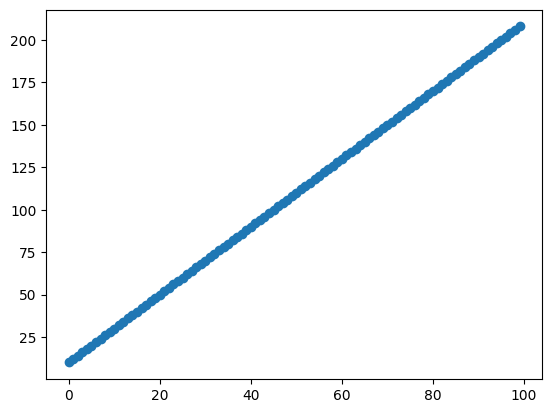

In [101]:

X = np.arange(0, 100)
# print(X)
y = 2 * X + 10
print(y)
plt.scatter(X, y)
plt.show()

Loss: 20916.622771613926


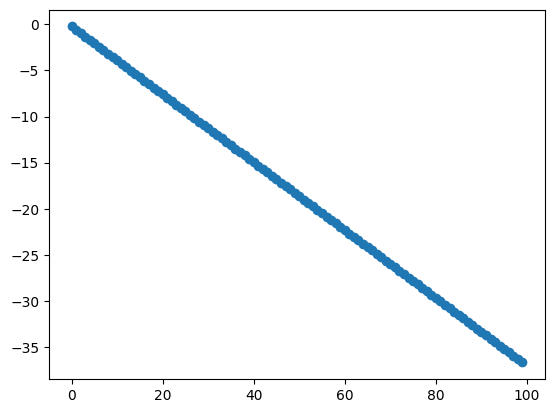

In [342]:
a = np.random.randn()
b = np.random.randn()
# print(a,b)
y_p = a*X + b
# print(y_p.round(5))
plt.scatter(X,y_p)

loss = np.mean((y - y_p) ** 2)

print("Loss:", loss)

High loss </br>
↓</br>
Adjust a,b slightly</br>
↓</br>
Lower loss</br>
↓</br>
Adjust again</br>
↓</br>
Lower loss</br>
↓</br>
Eventually close to y = 2x + 10</br>

In [398]:
losses = []
lr = 0.0001
for epoch in range(1000):
    y_pred = a * X + b

    loss = np.mean((y - y_pred) ** 2)

    losses.append(loss)
    print("epoch",epoch, ":-", loss)

    da = (-2/len(X)) * np.sum(X * (y - y_pred))
    db = (-2/len(X)) * np.sum(y - y_pred)
    # print(da,db)
    a = a - lr * da
    b = b - lr * db
print(a,b)
# print(losses[-1:-10:-1])

epoch 0 :- 3.7859308019242716e-12
epoch 1 :- 3.785546597559106e-12
epoch 2 :- 3.785162422871411e-12
epoch 3 :- 3.784778319975414e-12
epoch 4 :- 3.784394215089881e-12
epoch 5 :- 3.784010178911537e-12
epoch 6 :- 3.783626168270696e-12
epoch 7 :- 3.783242207225555e-12
epoch 8 :- 3.782858266450216e-12
epoch 9 :- 3.7824743738408435e-12
epoch 10 :- 3.78209052834846e-12
epoch 11 :- 3.781706709197019e-12
epoch 12 :- 3.781322933707008e-12
epoch 13 :- 3.780939206626295e-12
epoch 14 :- 3.780555498198741e-12
epoch 15 :- 3.780171840121605e-12
epoch 16 :- 3.779788213060711e-12
epoch 17 :- 3.779404648945286e-12
epoch 18 :- 3.779021111430062e-12
epoch 19 :- 3.778637596859323e-12
epoch 20 :- 3.778254125853027e-12
epoch 21 :- 3.777870710908447e-12
epoch 22 :- 3.777487333743573e-12
epoch 23 :- 3.777103983236493e-12
epoch 24 :- 3.776720678327593e-12
epoch 25 :- 3.776337400126875e-12
epoch 26 :- 3.775954174971659e-12
epoch 27 :- 3.775570981817582e-12
epoch 28 :- 3.775187828962196e-12
epoch 29 :- 3.774804711

In [1]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.11.0+cu128
12.8
True


In [5]:
import torch
import torch.nn as nn


In [3]:

X = torch.arange(0, 100, dtype=torch.float32).view(-1, 1)

y = 2 * X + 10
print(X)
print(X.shape)
print(y.shape)

tensor([[ 0.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.],
        [11.],
        [12.],
        [13.],
        [14.],
        [15.],
        [16.],
        [17.],
        [18.],
        [19.],
        [20.],
        [21.],
        [22.],
        [23.],
        [24.],
        [25.],
        [26.],
        [27.],
        [28.],
        [29.],
        [30.],
        [31.],
        [32.],
        [33.],
        [34.],
        [35.],
        [36.],
        [37.],
        [38.],
        [39.],
        [40.],
        [41.],
        [42.],
        [43.],
        [44.],
        [45.],
        [46.],
        [47.],
        [48.],
        [49.],
        [50.],
        [51.],
        [52.],
        [53.],
        [54.],
        [55.],
        [56.],
        [57.],
        [58.],
        [59.],
        [60.],
        [61.],
        [62.],
        [63.],
        [64.],
        [65.],
        [6

In [114]:
model = nn.Linear(1, 1)
print(model)
print(model.weight)
print(model.bias)
print(model.parameters)
criterion = nn.MSELoss()

Linear(in_features=1, out_features=1, bias=True)
Parameter containing:
tensor([[0.1431]], requires_grad=True)
Parameter containing:
tensor([0.0577], requires_grad=True)
<bound method Module.parameters of Linear(in_features=1, out_features=1, bias=True)>


In [110]:
losses = []
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.0001
)
for epoch in range(1000):

    pred = model(X)
    print(pred)
    loss = criterion(pred, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if epoch % 100 == 0:
        print(epoch, loss.item())

tensor([[ 0.8501],
        [ 1.1398],
        [ 1.4296],
        [ 1.7194],
        [ 2.0092],
        [ 2.2990],
        [ 2.5888],
        [ 2.8785],
        [ 3.1683],
        [ 3.4581],
        [ 3.7479],
        [ 4.0377],
        [ 4.3275],
        [ 4.6172],
        [ 4.9070],
        [ 5.1968],
        [ 5.4866],
        [ 5.7764],
        [ 6.0662],
        [ 6.3559],
        [ 6.6457],
        [ 6.9355],
        [ 7.2253],
        [ 7.5151],
        [ 7.8049],
        [ 8.0946],
        [ 8.3844],
        [ 8.6742],
        [ 8.9640],
        [ 9.2538],
        [ 9.5436],
        [ 9.8334],
        [10.1231],
        [10.4129],
        [10.7027],
        [10.9925],
        [11.2823],
        [11.5721],
        [11.8618],
        [12.1516],
        [12.4414],
        [12.7312],
        [13.0210],
        [13.3108],
        [13.6005],
        [13.8903],
        [14.1801],
        [14.4699],
        [14.7597],
        [15.0495],
        [15.3392],
        [15.6290],
        [15.

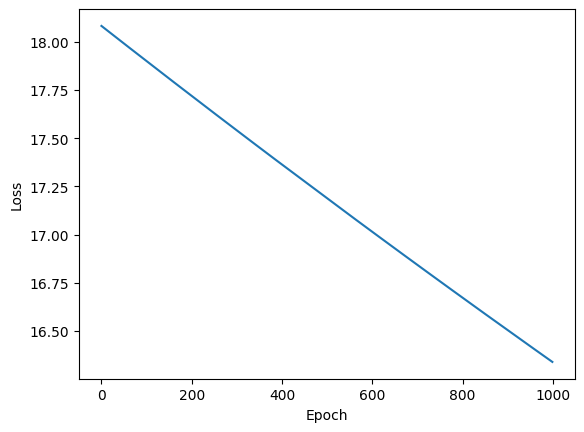

In [107]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()